# Rapport d'Analyse : Déterminants du Vote et Gentrification

**Auteurs :** Isaline JOUVE, Romain RATAJCZYK, Vincent VASYLCHENKO

## 1. Contexte et Objectifs
Les élections municipales de 2020 ont été marquées par une poussée écologiste dans les grandes villes et une abstention record. Ce projet vise à comprendre si ce vote est corrélé à des dynamiques de **gentrification** (évolution des revenus, des cadres, de l'éducation).

Nous croisons ici les données électorales (Ministère de l'Intérieur) et socio-économiques (INSEE) pour répondre à la problématique :
> *Les dynamiques socio-démographiques locales (gentrification) permettent-elles de prédire l'évolution du vote de gauche et écologiste ?*

Dans toute cette étude, nous nous intéressons aux résultats obtenus par le "bloc de gauche" aux élections municipales de 2014 et 2020. 
Nous considérons ici que ce bloc correspond à au groupe Europe Ecologie-Les Verts (LVEC), au groupe Ecologiste (LECO), au groupe Union de la Gauche (LUG), au groupe Divers Gauche (LDVG), au groupe (LSOC) et au groupe Liste du Parti de Gauche (LPG).

## Exécution du code

#### Installation automatique des dépendances si manquantes

In [1]:
# Installation automatique des dépendances si manquantes
! pip install -r "required_libraries.txt"

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 882.2/882.2 kB 66.6 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.1/2.1 MB 61.9 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5/5 [mapclassify] [openpyxl]


/opt/python/lib/python3.13/site-packages/nbformat/__init__.py:96: MissingIDFieldWarning: Cell is missing an id field, this will become a hard error in future nbformat versions. You may want to use `normalize()` on your notebooks before validations (available since nbformat 5.1.4). Previous versions of nbformat are fixing this issue transparently, and will stop doing so in the future.
  validate(nb)
/opt/python/lib/python3.13/site-packages/nbformat/__init__.py:96: DuplicateCellId: Non-unique cell id '5d2f7dc3' detected. Corrected to '1e358fcb'.
  validate(nb)
/opt/python/lib/python3.13/site-packages/nbformat/__init__.py:96: DuplicateCellId: Non-unique cell id '6ddd9105' detected. Corrected to 'cdd29609'.
  validate(nb)
/opt/python/lib/python3.13/site-packages/nbformat/__init__.py:96: DuplicateCellId: Non-unique cell id 'd3a2c9f7' detected. Corrected to '4f59ed2e'.
  validate(nb)
/opt/python/lib/python3.13/site-packages/nbformat/__init__.py:96: DuplicateCellId: Non-unique cell id '3b8adf

## Objectif 
Ce code effectue le premier traitement des bases de données qui seront utilisées pour ce projet. Il agrège dans un premier temps les bases de données produites par l'INSEE :
* Revenus et pauvreté des ménages
* Revenus localisés sociaux et fiscaux
* Diplômes-Formation

et dans un deuxième temps ajoute les résultats des élections présidentielles et communales de 2014, 2017, 2020 et 2022 qui ont été mis en forme dans le code "Data formatting".

Le code totalement reproductible est particulièrement lourd à exécuter. Aussi, le script vérifie 
si les données sont déjà chargées en mémoire (session active) ou si le fichier final est déjà présent (disponible sur le dépôt Git).
Si ces conditions sont remplies, l'étape de préparation est ignorée pour fluidifier la lecture du notebook.
Mais ce code le génère si besoin (pour vérifier la réplicabilité par exemple si vous le souhaitez !)

##### Chargement/Rechargement des données brutes...

- Chargement Population...


...

Nombre de communes conservées : 1675


,Code commune,Libellé de la commune,Code Nuance,Sexe,Nom,Prénom,Liste,Sièges / Elu,Sièges Secteur,Sièges CC,Voix,% Voix/Ins,% Voix/Exp,winner,D_elec_2014
0,01004,Ambérieu-en-Bugey,LDVD,M,FABRE,Daniel,PAROLE AUX AMBARROIS,27,0.0,7.0,2678.0,32.67,61.31,yes,0.0
1,01007,Ambronay,LDVG,F,LEVRAT,Gisèle,AMBRONAY POUR TOUS,14,0.0,2.0,610.0,34.46,46.78,yes,1.0
2,01034,Belley,LDVD,M,JIMENEZ,Christian,BELLEY NOUVEL HORIZON 2014,22,0.0,14.0,2029.0,35.72,51.17,yes,0.0
3,01160,Ferney-Voltaire,LDVD,M,RAPHOZ,Daniel,FERNEY-VOLTAIRE VALEURS COMMUNES,22,0.0,4.0,1075.0,26.41,50.45,yes,0.0
4,01185,Hauteville-Lompnes,LUDI,M,ARGENTI,Bernard,OSONS L'AVENIR,22,0.0,6.0,815.0,36.19,61.28,yes,0.0


Ci-dessous un aperçu de la base après filtrage et traitement :


### Statistiques descriptives sur les bases de données des municipales 

Dans cette partie, nous comparons les résultats des élections municipales de 2014 et 2020 en France métropolitaine.
Afin de rendre les résultats lisibles et de dégager des tendances sociologiques claires, nous avons agrégé les nombreuses nuances politiques administratives en 6 grands blocs homogènes :


| Bloc Politique | Codes Nuances (Admin) | Libellés inclus |
|---|---|---|
| ** BLOC GAUCHE & ÉCOLO** | `LVECE`, `LVEC`, `LECO`, `LUG`, `LDVG`, `LSOC`, `LPG` | *Europe Ecologie-Les Verts, Europe Ecologie-Les Verts, Ecologiste, Union de la Gauche, Divers Gauche, Parti socialiste, Parti de Gauche* |
| ** BLOC EXTRÊME GAUCHE** | `LEXG`, `LCOM`, `LFI`, `LRDG`, `LFG` | *Extrême gauche, Parti communiste français, La France insoumise, Parti radical de gauche, Front de Gauche* |
| ** BLOC CENTRE** | `LREM`, `LMDM`, `LUC`, `LDVC` | *La République en marche, Modem, Union du centre, Divers centre* |
| ** BLOC DROITE** | `LLR`, `LUD`, `LDVD`, `LUDI`, `LUMP` | *Les Républicains, Union de la droite, Divers droite, Union Démocrates et Indépendants, Union pour un Mouvement Populaire* |
| ** BLOC EXTRÊME DROITE** | `LDLF`, `LRN`, `LEXD`, `LFN` | *Debout la France, Rassemblement National, Extrême droite, Front National* |
| ** BLOC AUTRE** | `LDIV`, `LREG`, `LGJ`, `LNC` | *Divers, Régionaliste, Gilets jaunes, Non Communiqué* |


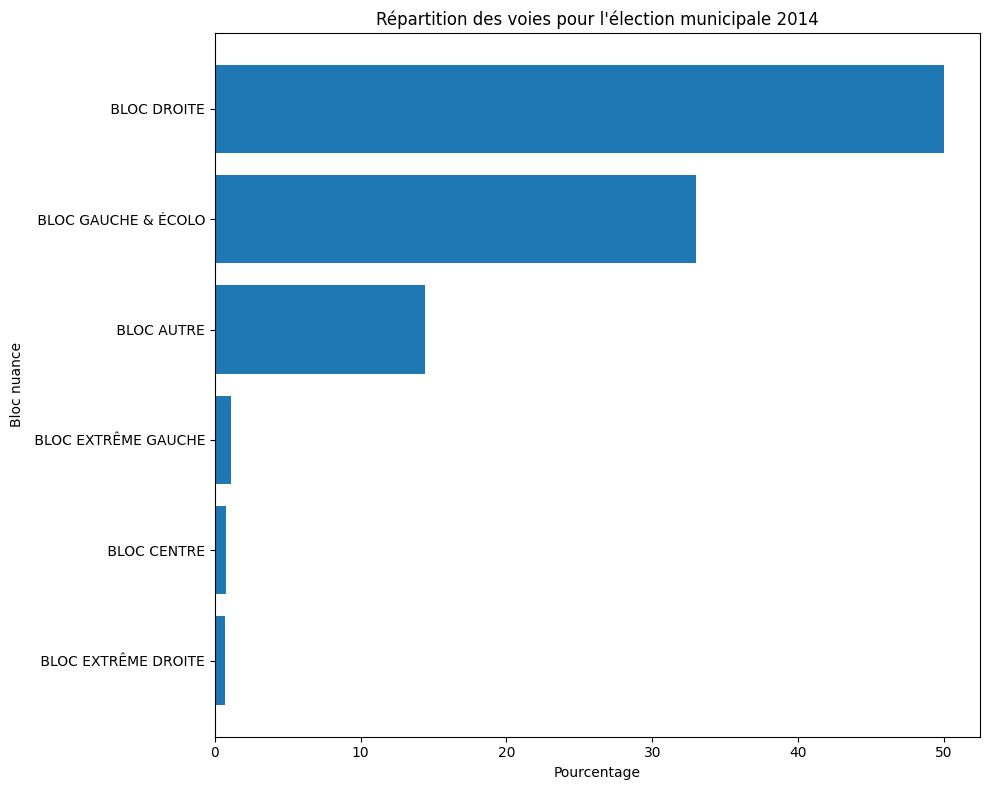

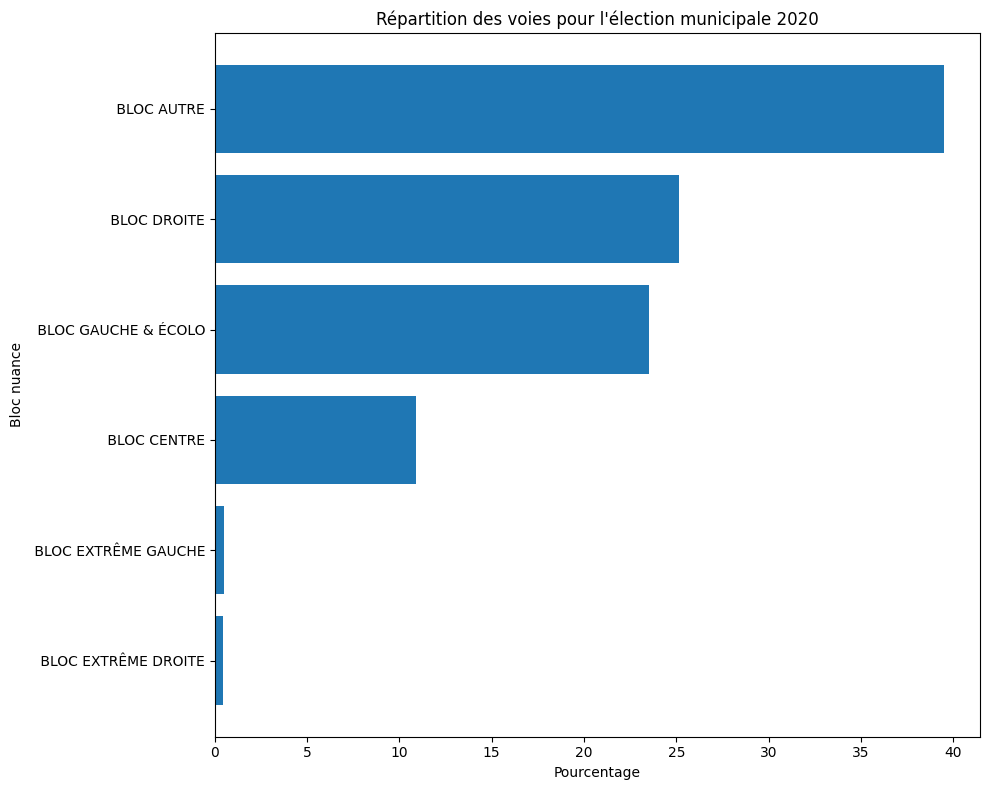

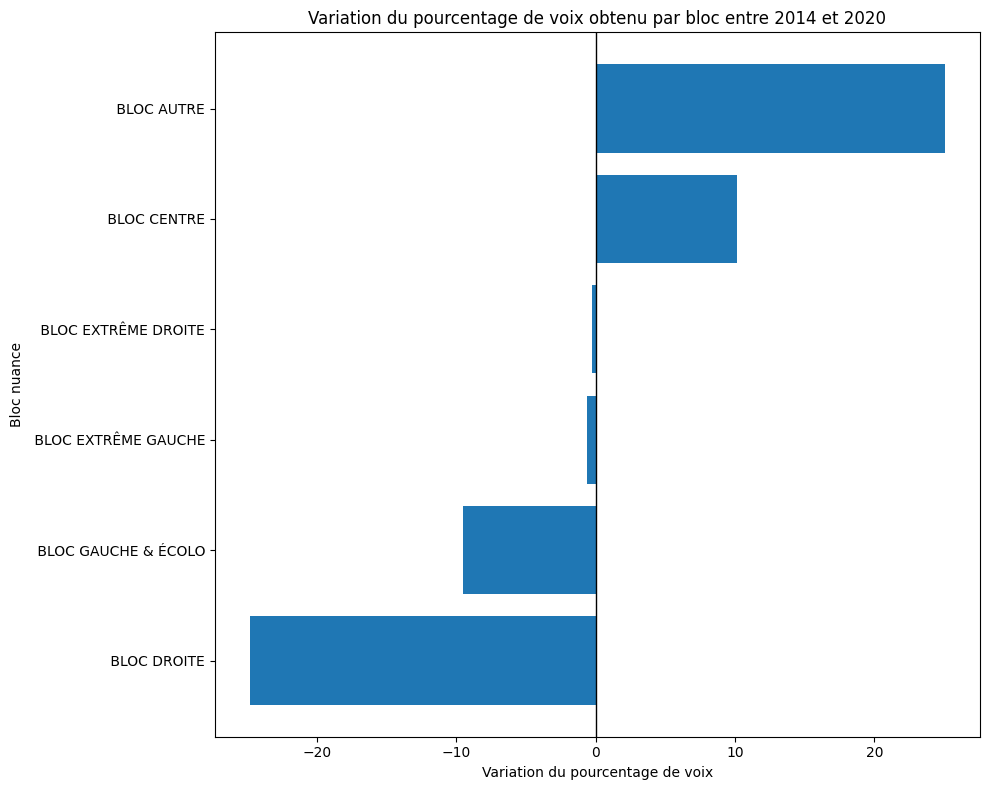


#### Analyse de l'évolution de l'offre politique (2014-2020)

La période entre 2014 et 2020 est marquée par une grande variation dans les listes présentées par les candidats aux élections municipales.

* En 2014, le panel de candidats est dominé par les nuances traditionnelles ("Divers Droite" et "Divers Gauche"). Au global, les blocs de Gauche et de Droite remportent près de 80 % des communes de plus de 3 500 habitants.
* En 2020, les résultats du "Bloc Centre" sont portés par l'émergence de LREM, qui participe à l'érosion du Bloc de Droite. 
* Par ailleurs, la forte progression (relative) du "Bloc Autre" souligne une limite des données : elle s'explique en partie par l'augmentation significative du nombre de communes où la nuance politique n'a pas été clairement identifiée ou communiquée ("Nuances Neutres" ou "Divers").


### Résultats de l'élection présidentielle 2022
Afin d'affiner notre analyse, nous introduisons ici les données du 1er tour de la présidentielle 2022 par commune.
L'objectif est de comparer le vote local (municipales) au vote national (présidentielles) sur les mêmes territoires.
A noter que les nuances politiques ne sont pas renseignés ; seuls les noms des candidats sont disponibles. Il faudra donc effectuer un mappage manuel pour les classer dans nos blocs politiques.
Des étapes de tri du vainqueur et de filtrage sont également nécessaires.

 Chargement du fichier : Elections présidentielles 2022 par commune.xlsx...
Chargement terminé : 35245 lignes.


,Code du département,Libellé du département,Code de la commune,Libellé de la commune,Etat saisie,Inscrits,Abstentions,% Abs/Ins,Votants,% Vot/Ins,...,Unnamed: 93,Unnamed: 94,Unnamed: 95,Unnamed: 96,Unnamed: 97,Unnamed: 98,Unnamed: 99,Unnamed: 100,Unnamed: 101,Unnamed: 102
0,01,Ain,001,L'Abergement-Clémenciat,Complet,645,108,16.74,537,83.26,...,3,0.47,0.58,12,M,DUPONT-AIGNAN,Nicolas,21,3.26,4.04
1,01,Ain,002,L'Abergement-de-Varey,Complet,213,38,17.84,175,82.16,...,3,1.41,1.75,12,M,DUPONT-AIGNAN,Nicolas,0,0.00,0.00
2,01,Ain,004,Ambérieu-en-Bugey,Complet,8765,2078,23.71,6687,76.29,...,43,0.49,0.66,12,M,DUPONT-AIGNAN,Nicolas,181,2.07,2.76
3,01,Ain,005,Ambérieux-en-Dombes,Complet,1282,234,18.25,1048,81.75,...,2,0.16,0.19,12,M,DUPONT-AIGNAN,Nicolas,27,2.11,2.63
4,01,Ain,006,Ambléon,Complet,103,23,22.33,80,77.67,...,0,0.00,0.00,12,M,DUPONT-AIGNAN,Nicolas,1,0.97,1.30


object


...

**Aperçu du résultat après attribution des nuances :**

,Code commune,Nom,code_nuance,% Voix/Exp
1,01001,MACRON,LREM,28.85
14,01002,MACRON,LREM,29.24
34,01004,LE PEN,LFN,25.12
46,01005,LE PEN,LFN,34.24
55,01006,MACRON,LREM,27.27


Enfin, cette base est exportée comme il se doit.

#### Statistiques descriptives sur les présidentielles de 2022

Le graphique et le tableau ci-dessous montrent le nombre de communes où chaque candidat est arrivé en tête au 1er tour.
On observe une disparité importante entre les candidats : Marine Le Pen et Emmanuel Macron remportent à eux deux plus de 31 000 communes (91 % des communes étudiées ici) et certains candidats ne sont en tête que dans une poignée de villages (moins de 10 pour Jadot, Hidalgo, Arthaud, Poutou).

Nous utilisons une échelle logarithmique pour mieux visualiser les grandes des petites valeurs, rendant ainsi lisibles les ordres de grandeur de tous les candidats sur un même graphique.


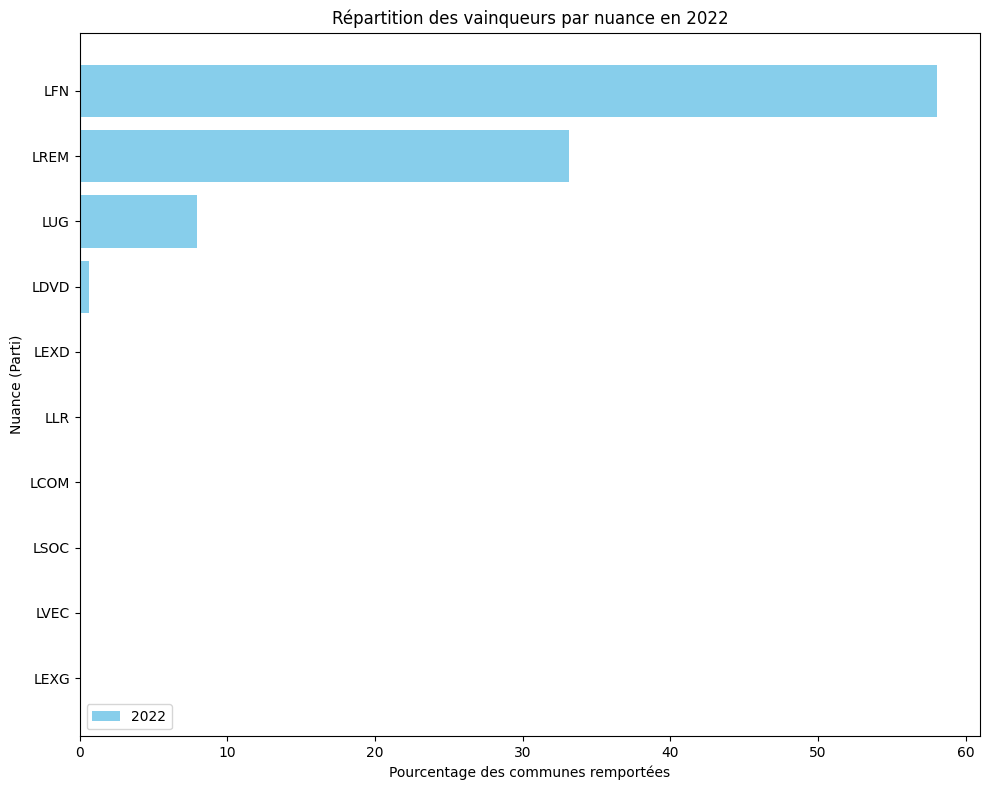

,Candidat,Nombre de Communes,Pourcentage (%),Nuance
0,LE PEN,20011,58.07,LFN
1,MACRON,11417,33.13,LREM
2,MÉLENCHON,2732,7.93,LUG
3,LASSALLE,212,0.62,LDVD
4,ZEMMOUR,31,0.09,LEXD
5,PÉCRESSE,24,0.07,LLR
6,ROUSSEL,10,0.03,LCOM
7,HIDALGO,9,0.03,LSOC
8,JADOT,8,0.02,LVEC
9,DUPONT-AIGNAN,4,0.01,LDVD


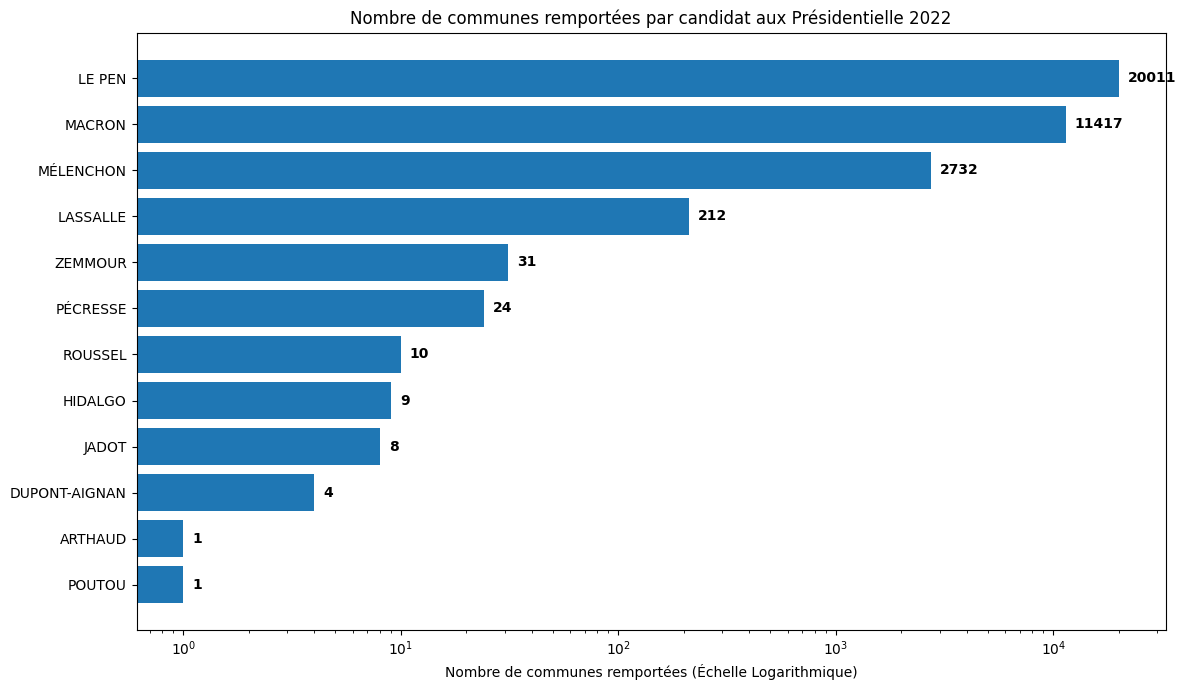



Ce graphique met en lumière une distorsion majeure entre la domination territoriale et le poids démographique réel. 

1. Une domination en trompe-l'œil : Bien que Marine Le Pen arrive en tête dans plus de 58 % des communes (soit environ 20 011 communes), cela ne s'est pas traduit par une victoire nationale. Cela illustre la fracture de densité : gagner beaucoup de petits villages ne suffit pas face aux métropoles densément peuplées.

2. Le contraste avec l'ancrage local : Il existe un décalage frappant avec les élections municipales. Alors que le vote RN est massif aux présidentielles dans ces 20 000 communes, le Rassemblement National ne parvient paradoxalement à remporter que très peu de mairies. 

 Cela souligne la différence entre un vote de contestation/opinion nationale et la capacité d'un parti à structurer une offre politique locale (trouver des candidats, monter des listes crédibles) face à une offre locale déjà ancrée.



### Elections présidentielle de 2017

Nous intégrons également les résultats du 1er tour de 2017 pour analyser la dynamique électorale sur un temps plus long.
Le traitement suit la même logique que pour 2022 : nettoyage géographique, restructuration des données pour isoler le vainqueur par commune et harmonisation des nuances politiques.


Chargement des données 2017...



#### Aperçu des données traitées

Voici un extrait de la base de données finale pour 2017


,Code commune,Nom,code_nuance,% Voix/Exp
0,01001,LE PEN,LFN,25.45
1,01002,LE PEN,LFN,27.27
2,01004,LE PEN,LFN,25.84
3,01005,LE PEN,LFN,32.80
4,01006,MÉLENCHON,LUG,24.68


Les données sont bien exportées.

Nombre de communes traitées en 2017 : 35281


,Code du département,Libellé du département,Code commune,Code de la commune,Libellé de la commune,Inscrits,Abstentions,% Abs/Ins,Votants,Exprimés,N°Panneau,Sexe,Nom,Prénom,Voix,% Voix/Ins,% Voix/Exp,code_nuance
0,1.0,Ain,01001,1,L'Abergement-Clémenciat,598,92,15.38,506,495,2,F,LE PEN,Marine,126,21.07,25.45,LFN
1,1.0,Ain,01002,2,L'Abergement-de-Varey,209,25,11.96,184,176,2,F,LE PEN,Marine,48,22.97,27.27,LFN
2,1.0,Ain,01004,4,Ambérieu-en-Bugey,8586,1962,22.85,6624,6452,2,F,LE PEN,Marine,1667,19.42,25.84,LFN
3,1.0,Ain,01005,5,Ambérieux-en-Dombes,1172,215,18.34,957,933,2,F,LE PEN,Marine,306,26.11,32.80,LFN
4,1.0,Ain,01006,6,Ambléon,99,20,20.2,79,77,9,M,MÉLENCHON,Jean-Luc,19,19.19,24.68,LUG


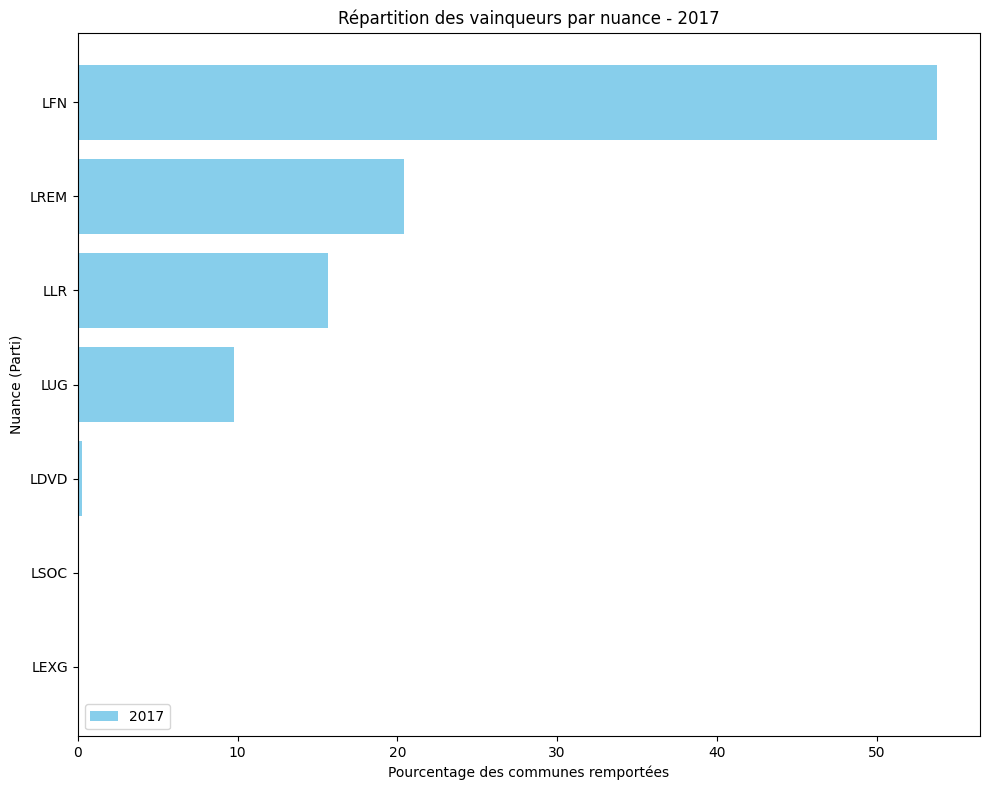

Candidats identifiés en 2017 : ['LE PEN' 'MÉLENCHON' 'MACRON' 'FILLON' 'DUPONT-AIGNAN' 'LASSALLE' 'HAMON'
 'ASSELINEAU' 'POUTOU']
Total des communes traitées (2017) : 35281


,Candidat,Nombre de Communes,Pourcentage (%),Nuance
0,LE PEN,18973,53.78,LFN
1,MACRON,7213,20.44,LREM
2,FILLON,5530,15.67,LLR
3,MÉLENCHON,3446,9.77,LUG
4,LASSALLE,78,0.22,LDVD
5,DUPONT-AIGNAN,23,0.07,LDVD
6,HAMON,16,0.05,LSOC
7,ASSELINEAU,1,0.00,LDVD
8,POUTOU,1,0.00,LEXG


Pour une meilleur lisibilité, l'histogramme de la répartition des vainqueurs est représenté en échelle logarithmique :

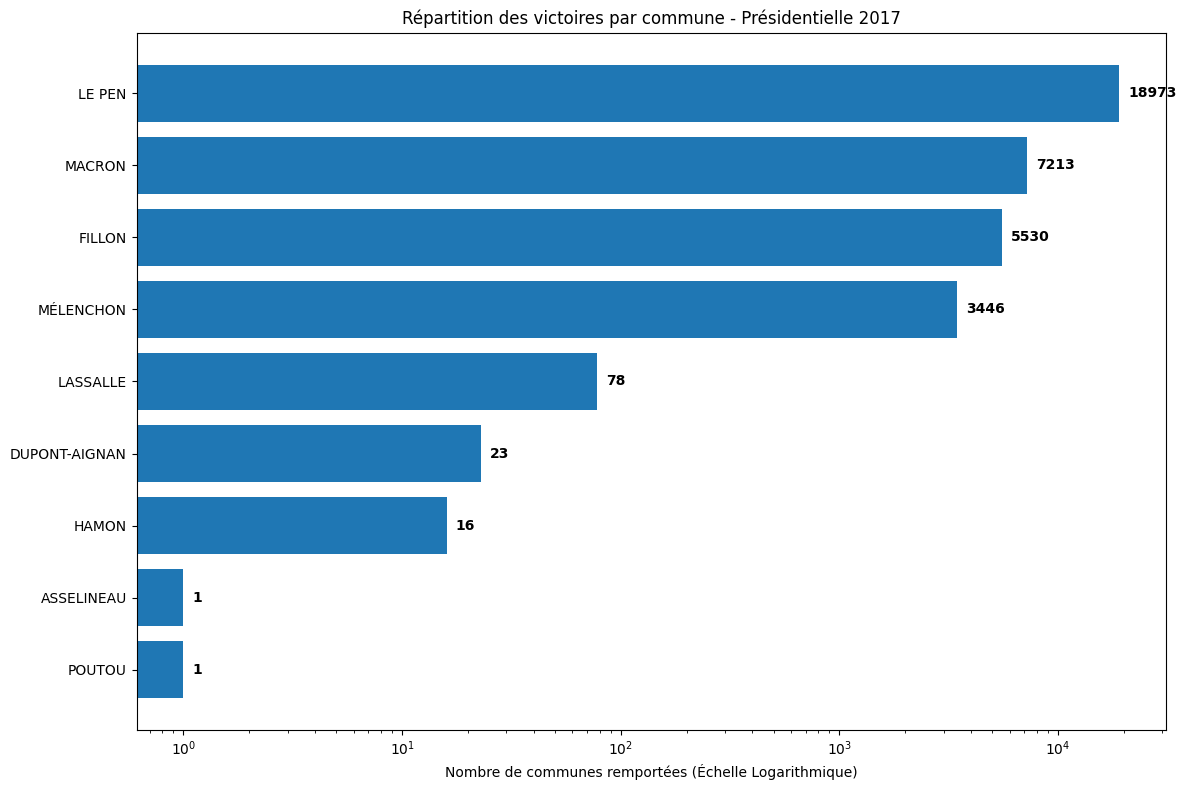

Les graphiques ci-dessus révèlent une configuration politique qui préfigure la recomposition de 2022 :

1.  L'hégémonie géographique du Front National (LFN) :
    * Tout comme en 2022, Marine Le Pen domine la carte des communes, arrivant en tête dans près de **19 000 localités** (soit plus de 53 % des communes françaises).

2.  La résistance de la Droite (Fillon) et l'effondrement de la Gauche (Hamon) :
    * François Fillon conserve une assise territoriale forte (3ème force,  près de5 500 communes), montrant que l'ancrage local de la droite traditionnelle résistait encore en 2017.
    * À l'inverse, le Parti Socialiste (Benoît Hamon) disparaît presque totalement de la carte des vainqueurs (moins de 20 communes), supplanté par Jean-Luc Mélenchon (LUG/LFI) qui capte le vote de gauche urbain et contestataire (environ 3 500 communes).

3.  La géographie spécifique du "Macronisme" naissant :
    * Emmanuel Macron remporte environ 7 200 communes. Moins étendu géographiquement que le vote Le Pen, son électorat est plus efficace démographiquement (villes moyennes et grandes), ce qui lui permet de virer en tête au niveau national.



####Comparaison entre les résultats de 2017 et 2022 via une matrice des corrélations

Nombre de communes comparées : 34458


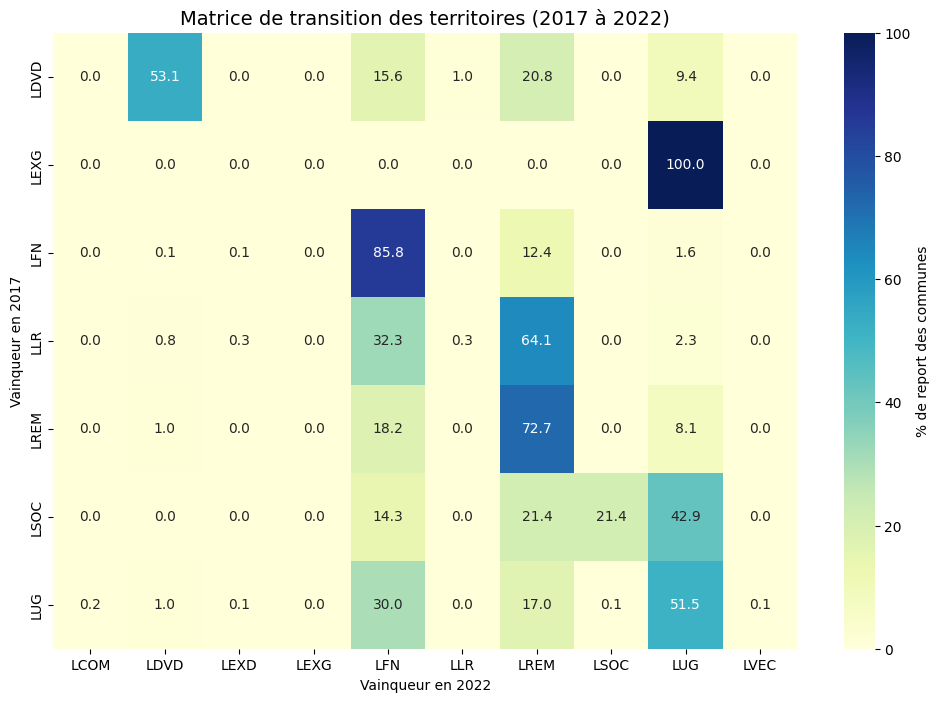

La matrice de transition ci-dessus permet de visualiser la **fidélité** des territoires et les **reports de voix** d'une élection à l'autre. Trois phénomènes sont observables :

1.  La rigidité du Rassemblement National (LFN) :
    * Le RN affiche le taux de fidélité le plus important : **85.8 %** des communes remportées par Marine Le Pen en 2017 ont de nouveau voté pour elle en 2022.
    * C'est un électorat territorialement extrêmement stable. Les pertes sont minimes (12.4% vers LREM), confirmant que les bastions conquis en 2017 sont restés ancrés à l'extrême droite.

2.  L'absorption de la Droite Républicaine (LLR) :
    * C'est le fait le plus marquant de la recomposition. Les communes gagnées par François Fillon (LLR) en 2017 ont littéralement disparu au profit des deux finalistes.
    * **64.1 %** de ces communes ont basculé vers **Emmanuel Macron (LREM)**.
    * **32.3 %** ont basculé vers **Marine Le Pen (LFN)**.
    * Cela illustre l'écartèlement de l'électorat de droite, absorbé par le centre ou l'extrême droite, ne laissant presque aucune commune à Valérie Pécresse en 2022.

3.  La "porosité" du vote contestataire (LUG -> LFN) :
    * Concernant les communes remportées par Jean-Luc Mélenchon en 2017 (LUG) si **51.5 %** restent fidèles à la gauche radicale (LFI), une part très importante (**30.0 %**) a basculé vers le **Rassemblement National (LFN)**.
    * Ce chiffre illustre, à l'échelle locale, la théorie des "vases communicants" du vote de colère dans les zones périurbaines ou désindustrialisées : quand la gauche recule, c'est souvent le RN qui en profite directement, plutôt que le centre.

4.  La consolidation du Bloc Central (LREM) :
    * Emmanuel Macron conserve **72.7 %** de ses conquêtes de 2017.
    * Cependant, il cède du terrain sur sa droite : **18.2 %** des communes qu'il avait gagnées en 2017 ont basculé vers Marine Le Pen en 2022, signe d'une radicalisation de certains territoires modérés ou d'une déception vis-à-vis du pouvoir en place.

**Conclusion :** Cette matrice confirme la disparition du clivage Gauche/Droite traditionnel au profit d'une **bipolarisation territoriale** entre le Bloc Central (qui a absorbé la droite classique) et le Bloc Nationaliste (qui s'enracine et grignote sur les terres de la gauche contestataire).


#### Influence de l'étiquette du maire élu en 2020 sur les résultats de l'élection de 2022

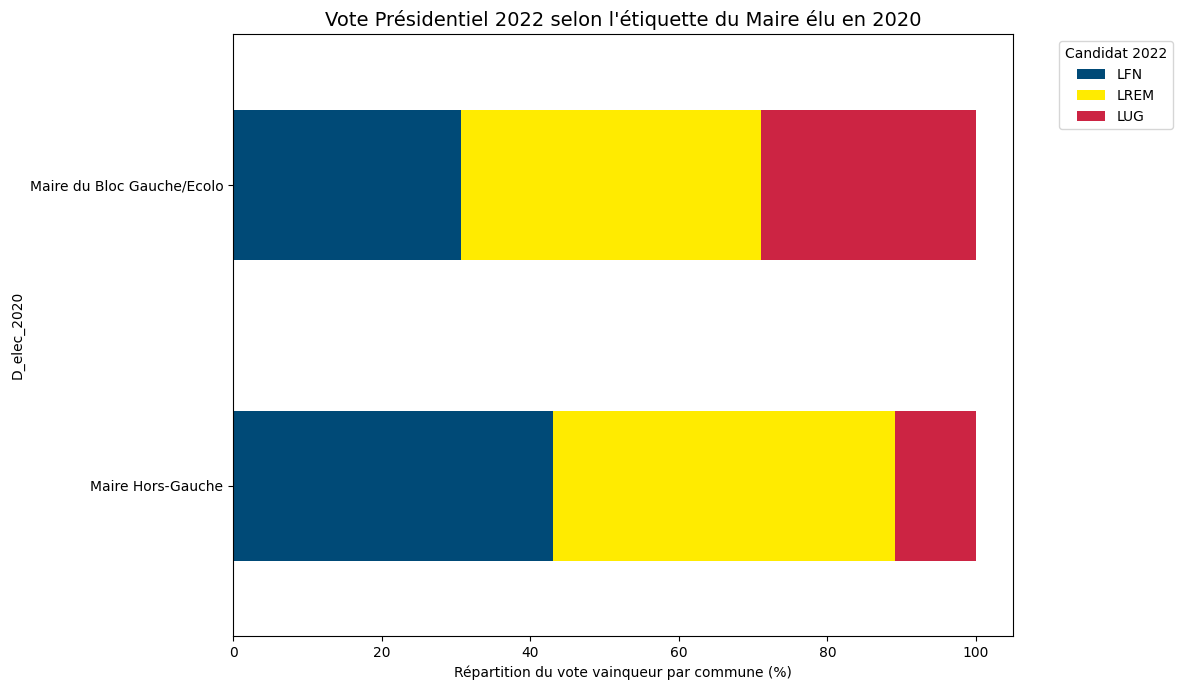

Ce graphique met en exergue une corrélation politique entre la couleur politique de la mairie 
(élue en 2020) et le comportement électoral lors de la présidentielle 2022. 

On observe une polarisation des territoires : les communes dirigées par le **Bloc Gauche/Écolo** agissent comme des **bastions** tout en jouant un rôle de "digue" freinant significativement le vote pour l'extrême droite. 

À l'opposé, les communes gérées par des maires **"Hors-Gauche"** (Droite, Centre ou Sans Étiquette) plébiscitent bien plus le Rassemblement National, tandis que le vote de gauche s'y effondre. Au centre de cette fracture territoriale, 
le vote Macron (LREM) fait figure de **constante**, conservant une base électorale solide et transversalement stable quelle que soit l'étiquette du maire.


Traitement électoral terminé : les scores du bloc Gauche/Écologiste ont été agrégés pour 1281 communes en 2014 et 705 communes en 2020.


Ci-dessous un aperçu de la variable du score de la gauche pour les présidentielles de 2022 : 


### Consolidation de la Base Finale
**Fusion des données électorales (Municipales & Présidentielles) et socio-économiques.**

* **Nombre de communes initial (base socio-demo) :** 31011
* **Nombre de communes final (après nettoyage NaN) :** 30717
* **Perte de données :** 294 communes (0.95%)


####  Statistiques des variables d'évolution (Y et X principaux)

...

 ### Standardisation des variables explicatives ($X$)

Dernière étape de préparation : la **standardisation (Z-score)** des variables explicatives : nos variables ont des unités très hétérogènes (Revenus en €, Population en habitants, Taux en %). Sans transformation, un coefficient associé au revenu (ex: 0.00003) serait écrasé par celui d'un taux (ex: 2.5), rendant la comparaison impossible.

Nous appliquons la transformation $Z = \frac{X - \mu}{\sigma}$ uniquement sur les variables explicatives ($X$).
Les variables cibles ($Y$) restent dans leur unité d'origine (points de pourcentage) pour préserver une interprétation intuitive (ex: *"Une augmentation de 1 écart-type de cadres augmente le score de gauche de 3 points"*).
Cette opération ne modifie ni la qualité du modèle ($R^2$), ni la significativité statistique (p-values), elle ne fait que rendre les coefficients beaucoup plus faciles à interpréter.


Variables transformées (X) : ['pop_2014', 'pop_2017', 'pop_2020', 'pop_2022', 'log_pop_2014', 'log_pop_2020', 'log_pop_2017', 'log_pop_2022', 'croissance_pop_14_20', 'croissance_pop_17_22', 'pct_sup_2014', 'pct_sup_2017', 'pct_sup_2020', 'pct_sup_2022', 'delta_pct_diplome_17_22', 'delta_pct_diplome_14_20', 'pct_cadres_2014', 'pct_cadres_2017', 'pct_cadres_2020', 'pct_cadres_2022', 'delta_pct_cadres_17_22', 'delta_pct_cadres_14_20', 'med_2013', 'med_2019', 'med_2016', 'log_med_16', 'log_med_13', 'log_med_19']
Variables conservées naturelles (Y) : ['COM', 'score_gauche_2014', 'score_gauche_2020', 'delta_score_gauche_pres', 'score_gauche_pres_2017', 'score_gauche_pres_2022', 'delta_score_gauche_municipales']
Fichier prêt pour l'analyse : /home/onyxia/work/Python-project/Data/merged/data_regression_std.csv


 ### Nous disposons d'un jeu de données homogène et nettoyé. 
Cet échantillon ne contient que les communes politiquement structurées (offre de gauche existante) et démographiquement significatives (> 3500 habs), ce qui garantit la fiabilité des résultats économétriques à venir.

Ci-dessous un aperçu des premières lignes de la base :


,COM,score_gauche_2014,score_gauche_2020,score_gauche_pres_2017,score_gauche_pres_2022,delta_score_gauche_pres,delta_score_gauche_municipales,pop_2014,pop_2017,pop_2020,...,pct_cadres_2020,pct_cadres_2022,delta_pct_cadres_17_22,delta_pct_cadres_14_20,med_2013,med_2019,med_2016,log_med_16,log_med_13,log_med_19
2,01004,38.69,0.00,29.24,34.45,5.21,-38.69,14022.0,14035.0,14288.0,...,0.056317,0.063212,0.007266,0.003308,19554.000000,20510.0,19721.000000,9.889439,9.880935,9.928668
27,01034,48.83,0.00,26.42,31.85,5.43,-48.83,8983.0,9103.0,9207.0,...,0.038647,0.039785,0.001960,0.000969,18549.000000,20030.0,18818.000000,9.842569,9.828171,9.904986
134,01160,49.55,0.00,29.70,40.07,10.37,-49.55,9337.0,9766.0,10612.0,...,0.134421,0.194857,0.059915,-0.026035,25508.333333,26770.0,26579.333333,10.187889,10.146760,10.195037
151,01185,38.72,0.00,29.42,31.71,2.29,-38.72,3829.0,4853.0,4824.0,...,0.046021,0.047081,0.017269,0.023136,20198.148148,21990.0,21040.500000,9.954204,9.913346,9.998343
203,01249,54.39,37.86,22.55,30.59,8.04,-16.53,9425.0,9963.0,10202.0,...,0.115664,0.110561,0.018987,0.024270,22710.666667,24860.0,24033.333333,10.087197,10.030590,10.121015


Le fichier final est exporté avec succès : /home/onyxia/work/Python-project/Data/merged/data_regression.csv


In [2]:
# Étape 1 : Préparation des données
%run "./notebooks/data_preparation.ipynb"

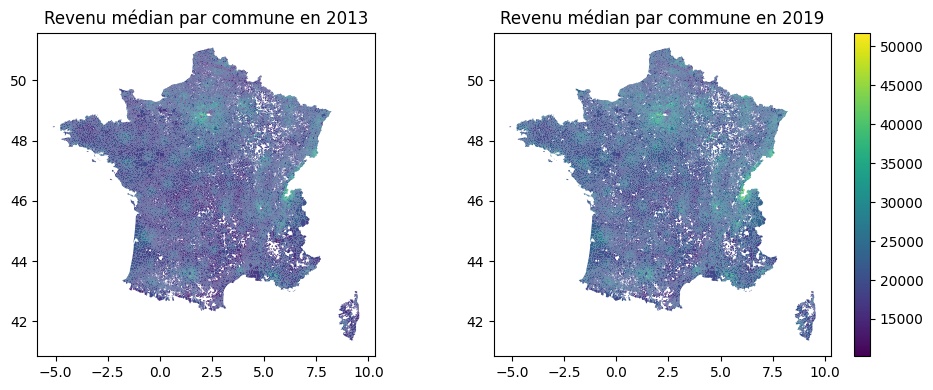

Le revenue médian est significativement plus élevé dans les communes proches de Paris et de la frontière avec la Suisse. Aussi, la proximité avec une grande métropole à un effet positif, qui est d'autant plus marqué en 2019.

Au global, on observe aussi une augmentation générale du revenu médian à travers le pays entre 2013 et 2019.

## Population communale

/opt/python/lib/python3.13/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: divide by zero encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)


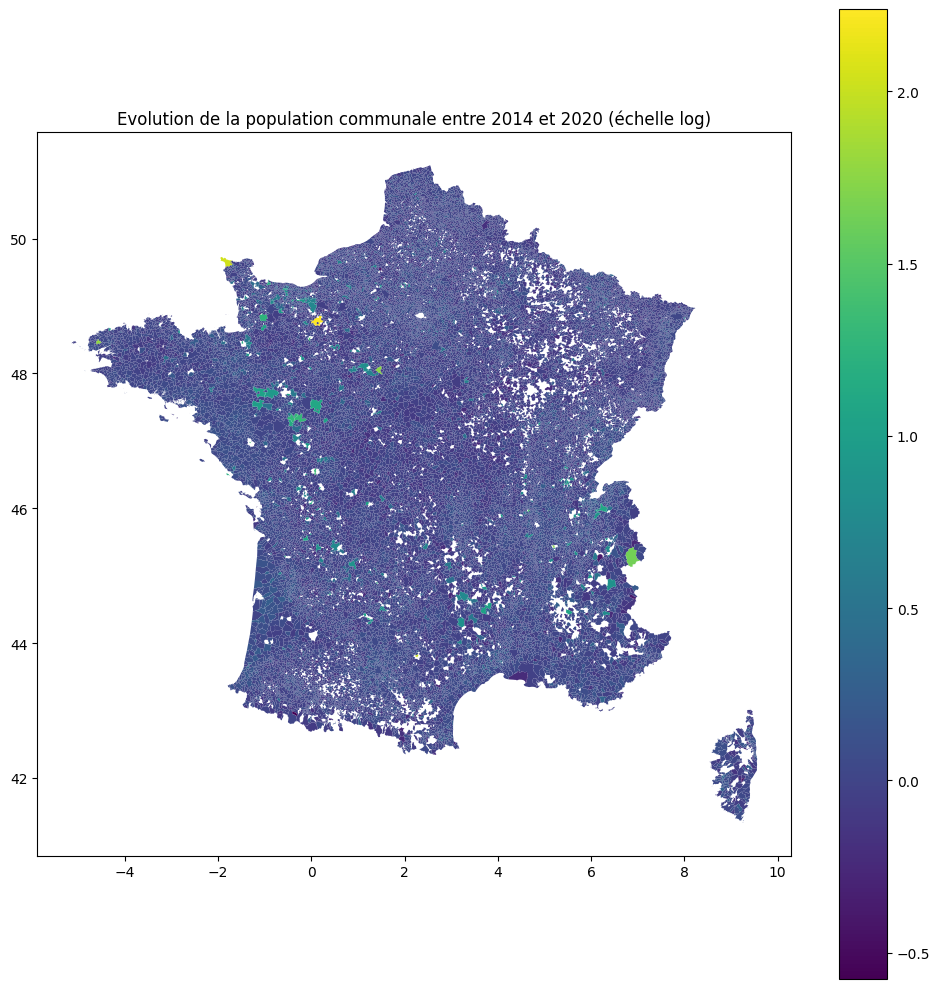


Dans une grande majorité de communes, la population est restée plutôt stable entre 2014 et 2020. Quelques communes échappent à cette règle et ont subit une forte augmentation de leur nombre d'habitant sur la période : elles se retrouvent notamment en Normandie, dans le pays de Loire, en Savoie ainsi que dans le sud et l'ouest du Massif Central.

## Part de diplomés du supérieur par communes

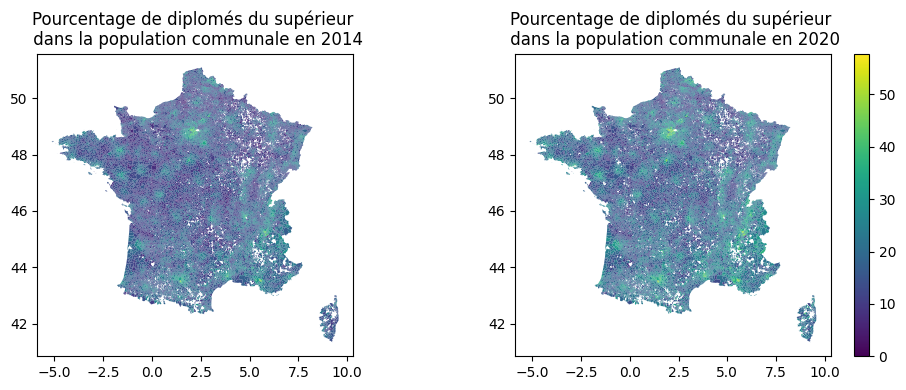

Comme attendu, le pourcentage de diplômés du supérieur est sensiblement plus important dans les banlieues de grandes métropoles comme Paris, Lyon, Toulouse, Marseille... Au niveau national, on constate une hausse globale de la part de diplômés du supérieur dans la population.

Par ailleurs, l'évolution de la part de diplômés du supérieur sur la période 2014-2020 est très variable enter les communes.

On observe dans les graphes suivants une augmentation au global plus marqué pour la Bretagne, la région parisienne élargie et la vallée du Rhône.
Au contraire, les diplômés se font plus rares dans les communes reculées du grand Est, de la diagonale du vide et des Pyrénées.


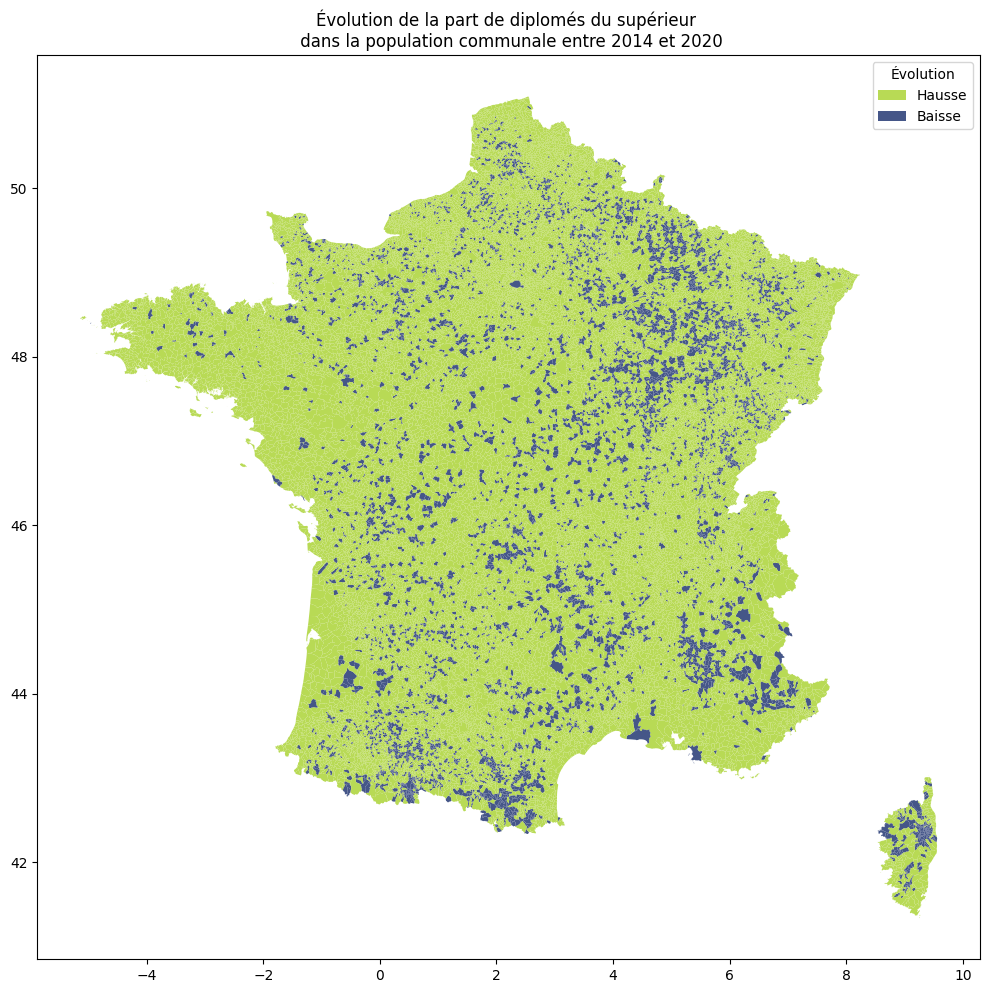

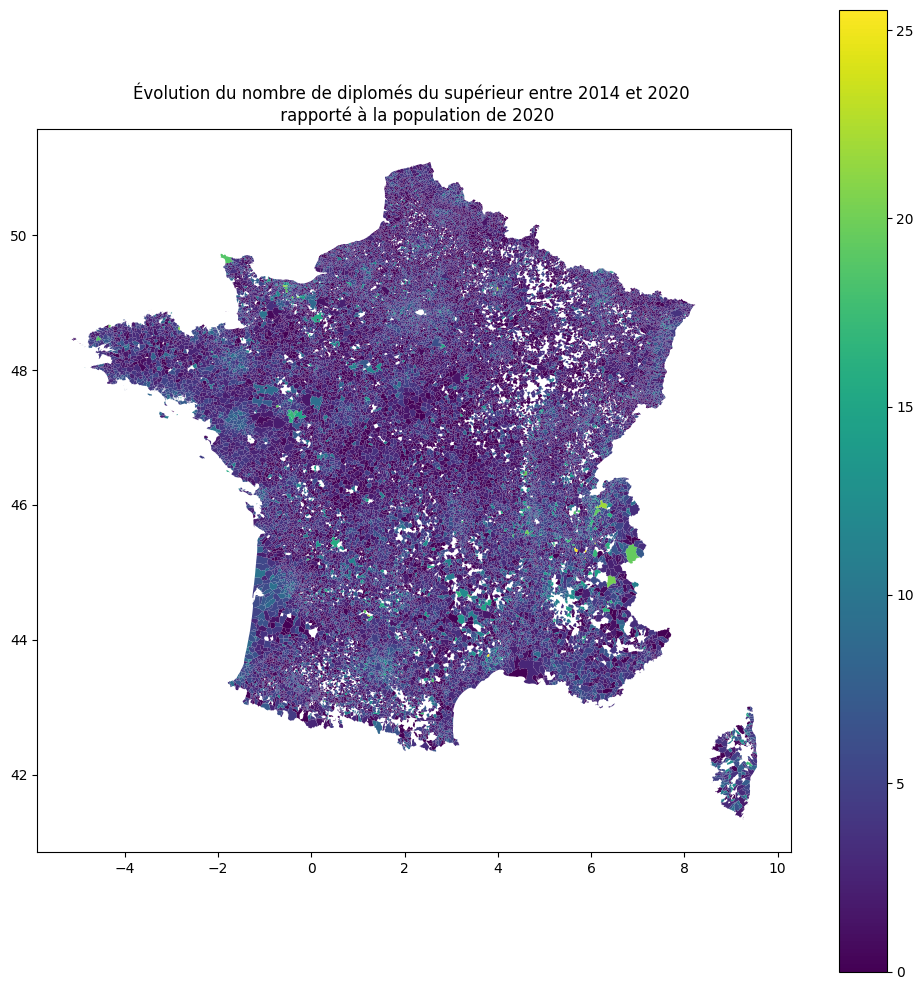

In [ ]:
# Étape 2 : Géoreprésentation des données des élections municipales
%run "./notebooks/Geo representation.ipynb"


In [14]:
# Étape 3 : Régressions et Statistiques
%run "./notebooks/regression_statsmodel.ipynb"


## Etude des données municipales

Avant cette analyse, nous avons formaté et standardisé les variables utilisées.

 * Transformation logarithmique : Les variables de richesse et de population ont été passées au logarithme avant toute standardisation pour éviter la création de valeurs manquantes (NaN) sur des valeurs centrées-réduites négatives

 * Choix des Variables : Utilisation stricte de taux (%) (Cadres, Diplômés) plutôt que de valeurs absolues pour éviter une multicolinéarité forte avec la variable de population.

 * Standardisation (Z-Score) : Appliquée uniquement aux variables explicatives (X) pour comparer les coefficients (coeffs beta), mais pas à la variable cible (Y = score gauche année X ou delta score) pour conserver l'interprétation en points de pourcentage de voix.


Nous commencons par étudier une simple régression linéaire du score du bloc de gauche à l'élection municipale de 2020
en fonction du score de 2014 et des variables socios de cette année

Régression sur la formule : score_gauche_2020 ~ score_gauche_2014 + log_pop_2020 + log_med_19 + pct_sup_2020
                            OLS Regression Results                            
Dep. Variable:      score_gauche_2020   R-squared:                       0.078
Model:                            OLS   Adj. R-squared:                  0.075
Method:                 Least Squares   F-statistic:                     23.24
Date:                Sun, 28 Dec 2025   Prob (F-statistic):           1.62e-18
Time:                        21:16:48   Log-Likelihood:                -5658.5
No. Observations:                1198   AIC:                         1.133e+04
Df Residuals:                    1193   BIC:                         1.135e+04
Df Model:                           4                                         
Covariance Type:                  HC1                                         
                        coef    std err          z      P>|z|      [0.025      0.975]
---------------

Les résultats du tableau précédent illustre la problématique d'instabilité de l'offre politique locale
qui nuit à la régression linéaire. Pour palier à ce problème, nous avons choisit de ne travailler que sur les communes présentant un
score strictement positif en 2014 et 2020, ce qui réduit grandement le nombre de ligne dans notre dataset

Données chargées : 1198 communes.
FILTRAGE:
Communes totales : 1198
Communes avec structure gauche stable (Test) : 371
Perte de 827 communes instables.

 RÉSULTATS DU TEST
Formule : score_gauche_2020 ~ score_gauche_2014 + log_pop_2020 + log_med_19 + pct_sup_2020
                            OLS Regression Results                            
Dep. Variable:      score_gauche_2020   R-squared:                       0.360
Model:                            OLS   Adj. R-squared:                  0.353
Method:                 Least Squares   F-statistic:                     49.78
Date:                Sun, 28 Dec 2025   Prob (F-statistic):           1.95e-33
Time:                        21:16:48   Log-Likelihood:                -1572.7
No. Observations:                 371   AIC:                             3155.
Df Residuals:                     366   BIC:                             3175.
Df Model:                           4                                         
Covariance Type:          

Dans cette nouvelle régression, la variable du score de 2014 est de loin
le meilleur indicateur du score réalisé à l'élection municipale suivante

En sélectionnant les commues "stables" le coefficient du score de 2014 passe de -0.21 à 0.67.
Initialement, ce résultat négatif suggérait un effondrement structurel des bastions historiques de gauche.Mais,
ce résultat était faussé par l'instabilité de l'offre politique locale (apparition/disparition de listes créant des scores de 0 artificiels).
A titre de correction, nous avons filtré pour étudier uniquement les communes ayant une offre stable (présence de liste de gauche en 2014 ET 2020).

L'autocorrélation est rétablie. L'inertie du vote existe toujours ; l'anomalie était TECHNIQUE et non POLITIQUE.


...

Régression sur la formule : score_gauche_pres_2022 ~ score_gauche_pres_2017 + log_pop_2022 + log_med_19 + pct_sup_2022
                              OLS Regression Results                              
Dep. Variable:     score_gauche_pres_2022   R-squared:                       0.737
Model:                                OLS   Adj. R-squared:                  0.737
Method:                     Least Squares   F-statistic:                 1.325e+04
Date:                    Sun, 28 Dec 2025   Prob (F-statistic):               0.00
Time:                            21:16:48   Log-Likelihood:                -86444.
No. Observations:                   30717   AIC:                         1.729e+05
Df Residuals:                       30712   BIC:                         1.729e+05
Df Model:                               4                                         
Covariance Type:                      HC1                                         
                             coef    std err       

Dans cette première analyse, nous regressons les niveaux de score réalisés en 2022 et 2017. 

Dans ce cas aussi, l'inertie reste le facteur dominant dans la dynamique de vote, suivit par le clivage culturel, et la richesse reste un frein

Régression sur la formule : delta_score_gauche_pres ~ + croissance_pop_17_22 + log_med_19 + delta_pct_diplome_17_22
                               OLS Regression Results                              
Dep. Variable:     delta_score_gauche_pres   R-squared:                       0.060
Model:                                 OLS   Adj. R-squared:                  0.060
Method:                      Least Squares   F-statistic:                     602.3
Date:                     Sun, 28 Dec 2025   Prob (F-statistic):               0.00
Time:                             21:16:48   Log-Likelihood:                -89227.
No. Observations:                    30717   AIC:                         1.785e+05
Df Residuals:                        30713   BIC:                         1.785e+05
Df Model:                                3                                         
Covariance Type:                       HC1                                         
                              coef    std er

En regressant maintenant les deltas score entre eux, nous remarquons : 
 * Un changement de signe pour le revenu (log_med_19) : contrairement au modèle de niveau,
 le coefficient devient positif (+0,94). La gauche progresse désormais plus vite dans les communes les plus aisées (embourgeoisement du vote),
 ce qui conforte notre intuition première.

 * Moteur éducatif (delta_pct_diplome) : l'augmentation locale du niveau de diplôme est un levier direct
 de croissance pour la gauche (+0,34). 

 * Dynamique démographique (croissance_pop) : les communes en forte croissance favorisent
 le bloc de gauche (+0,29), suggérant une "importation" de nouveaux électeurs de gauche
 (les nouveaux arrivants sont souvent des jeunes actifs ou diplomés, qui importent un vote de gauche).

 * Une poussée politique (Intercept) :  à sociologie constante, la gauche progresse de +1,17 point, reflétant une dynamique politique nationale favorable entre 2017 et 2022.

En comparant les deux analyses que nous avons réalisé, on observe que : 
 * Le modèle national est beaucoup plus robuste (R^2 = 0.737) que le modèle local (R^2 = 0.36).
 Cela indique que le vote présidentiel est très structuré par des déterminants sociologiques lourds,
 alors que le vote municipal dépend à plus de 60 % de facteurs non modélisés ici (personnalité du
 maire, enjeux de voirie, ancrage local).

 * Au niveau national, toutes les variables (Revenus, Diplômes, Population) sont hautement
 significatives (p < 0.001). Le vote est clairement idéologique et aligné sur des clivages de
 classe et de culture. Au contraire, au niveau local seule l'inertie historique est significative.
 Les variables sociologiques comme le diplôme (p=0.168), le revenu (p=0.075) ou
 la population (p=0.093) ne sont pas significatives au seuil standard de 5 %. Cela confirme que
 la sociologie "nationale" s'efface devant les logiques de gestion locale.

 * L'inertie de vote est fortement présente. Dans les deux cas, le score passé est LA variable
 la plus déterminante, mais l'effet est plus "pur" au niveau national. Néanmoins même en étant
 la seule variable significative au niveau local,, elle ne suffit pas à expliquer la majorité de
 la variance, montrant que les "fiefs" peuvent basculer sur des enjeux locaux déconnectés de la
 tendance nationale.

In [ ]:

# Étape 4 : Exploration Machine Learning
#%run "./notebooks/ML_exploration.ipynb"